In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

from scipy.stats import uniform, multivariate_normal

sys.path.append(os.path.join(os.getcwd(), "../../"))
from smcpy.mcmc.vector_mcmc import VectorMCMC
from smcpy.mcmc.vector_mcmc_kernel import VectorMCMCKernel
from smcpy import AdaptiveSampler as Sampler
from smcpy.paths import GeometricPath

from toy_helpers import M_HF, M_LF, generate_noisy_data

In [ ]:
# Data generation details
STD_DEV = 2.5
theta_0 = 1/2
theta_1 = 1
THETA_TRUE = np.array([[theta_0, theta_1]])
NUM_PARTICLES = 1000

In [ ]:
def plot_target_boxplots(true_values, **series):
    """Plot box plots for each parameter and series over the phi sequence.

    Args:
        true_values: array-like of true parameter values in param order
        **series: label=(targets_list, phi_sequence) for each SMC run
    """
    first_targets, _ = next(iter(series.values()))
    param_names = first_targets[0].param_names
    n_params = len(param_names)
    n_series = len(series)

    fig, axes = plt.subplots(
        n_params,
        n_series,
        sharex="col",
        sharey="row",
        figsize=(4 * n_series, 3 * n_params),
    )
    axes = np.atleast_2d(axes)

    for col, (label, (targets, phi_sequence)) in enumerate(series.items()):
        positions = np.arange(len(phi_sequence))
        box_width = 0.6
        for row, (name, true_val) in enumerate(zip(param_names, true_values)):
            ax = axes[row, col]
            ax.boxplot(
                [target.params[:, row] for target in targets],
                positions=positions,
                widths=box_width,
                patch_artist=True,
                manage_ticks=False,
            )
            ax.axhline(
                true_val,
                color="r",
                linestyle="--",
                linewidth=1.5,
                label="true value",
                alpha=0.7,
            )
            ax.grid(True)
            if col == 0:
                ax.set_ylabel(f"${name}$")
        axes[0, col].set_title(label + f" ({len(targets)} steps)")

    for col in range(n_series):
        axes[-1, col].set_xlabel("step")

    axes[0, -1].legend(loc="upper right")
    plt.tight_layout()
    plt.savefig("high_fidelity_test.png")
    plt.show()

In [4]:
np.random.seed(42)
noisy_data = generate_noisy_data(THETA_TRUE, STD_DEV)

In [5]:
priors = [uniform(-3, 3), uniform(-2, 8)]
vector_mcmc = VectorMCMC(M_HF, noisy_data, priors, STD_DEV)

# initialize from prior
mcmc_kernel = VectorMCMCKernel(vector_mcmc, param_order=("theta_0", "theta_1"))
smc = Sampler(mcmc_kernel=mcmc_kernel, show_progress_bar=True)
reg_step_list, mll_list = smc.sample(
    num_particles=NUM_PARTICLES,
    num_mcmc_samples=5,
    target_ess=0.5
)
reg_phi_list = smc.phi_sequence

[ mutation ratio: 0.9: : 100.00%|██████████| phi: 1.00000/1.0 [00:09<00:00      


In [6]:
# initialize from proposal
proposal_dist = multivariate_normal(mean=np.array([1/20, 1]), cov= np.array([[0.5, 0], [0, 1]]))
mcmc_kernel = VectorMCMCKernel(
    vector_mcmc, param_order=("theta_0", "theta_1"), path=GeometricPath(proposal=proposal_dist)
)
smc = Sampler(mcmc_kernel=mcmc_kernel, show_progress_bar=True)
prop_step_list, mll_list = smc.sample(
    num_particles=NUM_PARTICLES,
    num_mcmc_samples=5,
    target_ess=0.5
)
prop_phi_list = smc.phi_sequence

[ mutation ratio: 0.916: : 100.00%|██████████| phi: 1.00000/1.0 [00:09<00:00       


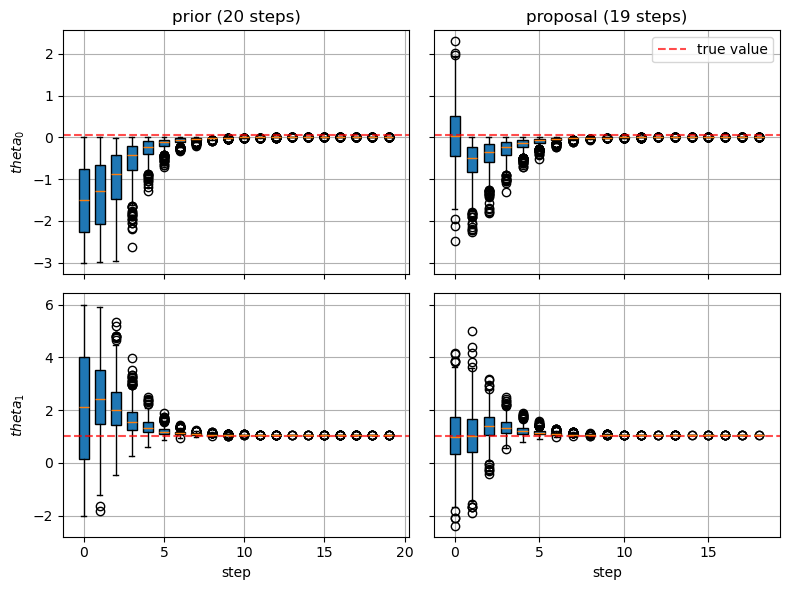

In [7]:
plot_target_boxplots(
    THETA_TRUE.flatten(),
    prior=(reg_step_list, reg_phi_list),
    proposal=(prop_step_list, prop_phi_list),
)

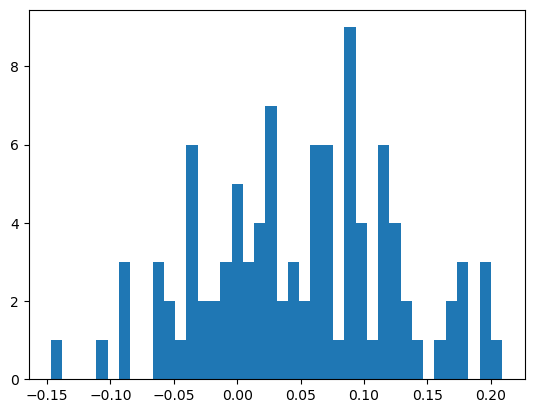

In [8]:
samples = np.random.normal(0.05, 0.08, 100)
plt.hist(samples, bins = 40);

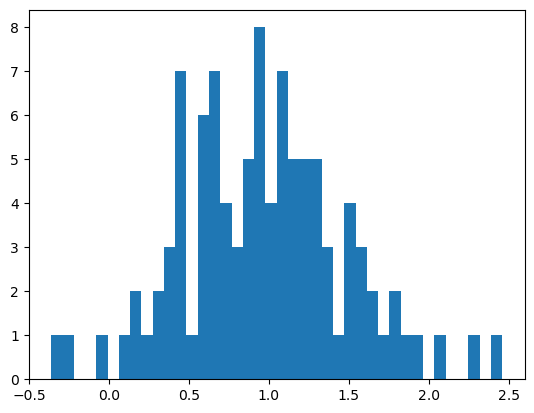

In [9]:
samples = np.random.normal(1, 0.5, 100)
plt.hist(samples, bins = 40);